In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split

# The code snippet from sklearn.model_selection import train_test_split is used to import a function from the scikit-learn library in Python. 
# This function is a core utility in machine learning for splitting a dataset into training 
# and testing subsets to ensure unbiased model evaluation

### Revision of ols method

In [2]:
data = pd.read_csv('CSV_file\\General_Stores.csv')

In [3]:
data.head()

,Footfalls,DailySales
0,10,5000
1,15,7800
2,18,11000
3,25,12500
4,33,16000


In [4]:
import statsmodels.formula.api as smf

In [5]:
x = data['Footfalls']
y = data['DailySales']
model = smf.ols('DailySales~Footfalls', data = data).fit()

In [6]:
model.params

Intercept    957.752809
Footfalls    472.134831
dtype: float64

In [7]:
model.pvalues

Intercept    0.284311
Footfalls    0.000017
dtype: float64

In [8]:
model.tvalues

Intercept     1.198820
Footfalls    16.088575
dtype: float64

In [9]:
X_test = pd.DataFrame([12, 23], columns = ['Footfalls'])
X_test

,Footfalls
0,12
1,23


In [10]:
pred = model.predict(X_test)

In [11]:
pred

0     6623.370787
1    11816.853933
dtype: float64

# ⇨MLR Model:: Predicting Sales based on advertising on TV, Radio, Newspaper

In [12]:
data = pd.read_csv('CSV_file\\advertising.csv')

In [13]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [15]:
data.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [16]:
data.select_dtypes(include = ['number']).corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


In [17]:
data.shape

(200, 4)

In [18]:
## define independent or dependent variable
X = data[['TV', 'Newspaper', 'Radio']]
Y = data['Sales']
print('--Independent/predictors variable--')
print(X.head())
print()
print('--Target/dependent variable--')
print(Y.head())

--Independent/predictors variable--
      TV  Newspaper  Radio
0  230.1       69.2   37.8
1   44.5       45.1   39.3
2   17.2       69.3   45.9
3  151.5       58.5   41.3
4  180.8       58.4   10.8

--Target/dependent variable--
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


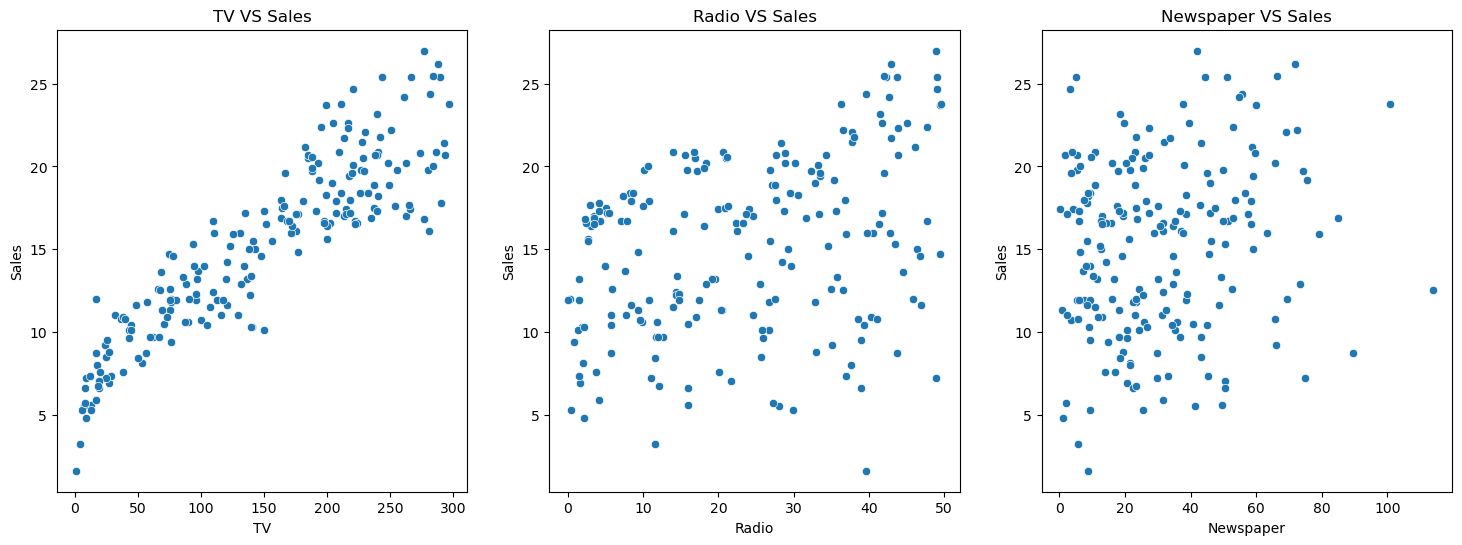

In [56]:
## PLotting scatter plot

plt.figure(figsize = (18, 6))

# scatter plot b/w TV and Sales
plt.subplot(1, 3, 1)
sns.scatterplot(x = data['TV'], y = data['Sales'])
plt.title('TV VS Sales')
plt.xlabel('TV')
plt.ylabel('Sales')

# scatter plot b/w Radio and Sales
plt.subplot(1, 3, 2)
sns.scatterplot(x = data['Radio'], y = data['Sales'])
plt.title('Radio VS Sales')
plt.xlabel('Radio')
plt.ylabel('Sales')

# scatter plot b/w News and Sales
plt.subplot(1, 3, 3)
sns.scatterplot(x = data['Newspaper'], y = data['Sales'])
plt.title('Newspaper VS Sales')
plt.xlabel('Newspaper')
plt.ylabel('Sales')

plt.show()

In [20]:
## Here, TV shows a strong relationship with Sales

In [57]:
## check any predictors is co-related to another predictors of X
X.corr()

,const,TV,Newspaper,Radio
const,NaN,NaN,NaN,NaN
TV,NaN,1.000000,0.033128,0.065938
Newspaper,NaN,0.033128,1.000000,0.341599
Radio,NaN,0.065938,0.341599,1.000000


### Compute co-related matrix

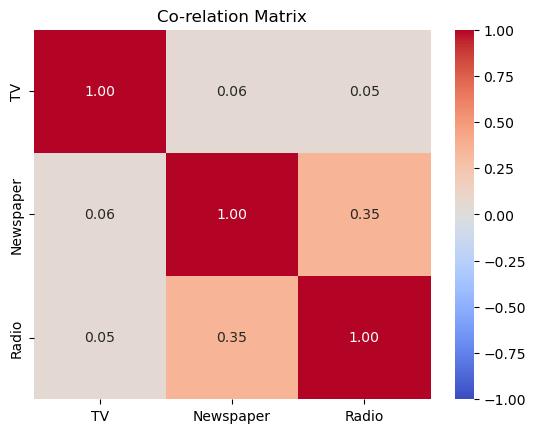

                 TV  Newspaper     Radio
TV         1.000000   0.056648  0.054809
Newspaper  0.056648   1.000000  0.354104
Radio      0.054809   0.354104  1.000000


In [22]:
corelation_matrix = X.corr()

sns.heatmap(corelation_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', vmin = -1, vmax = 1)
plt.title('Co-relation Matrix')
plt.show()

print(corelation_matrix)

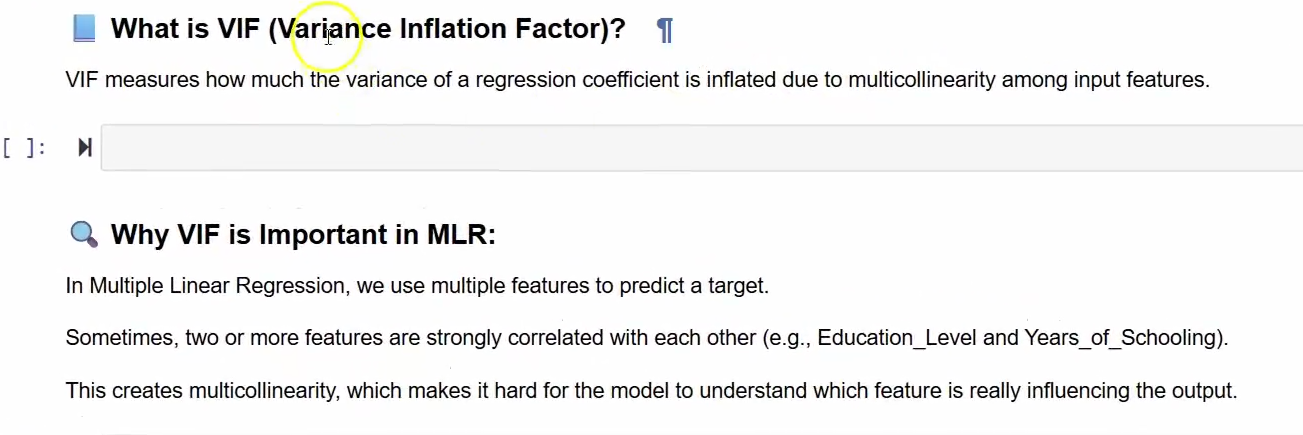

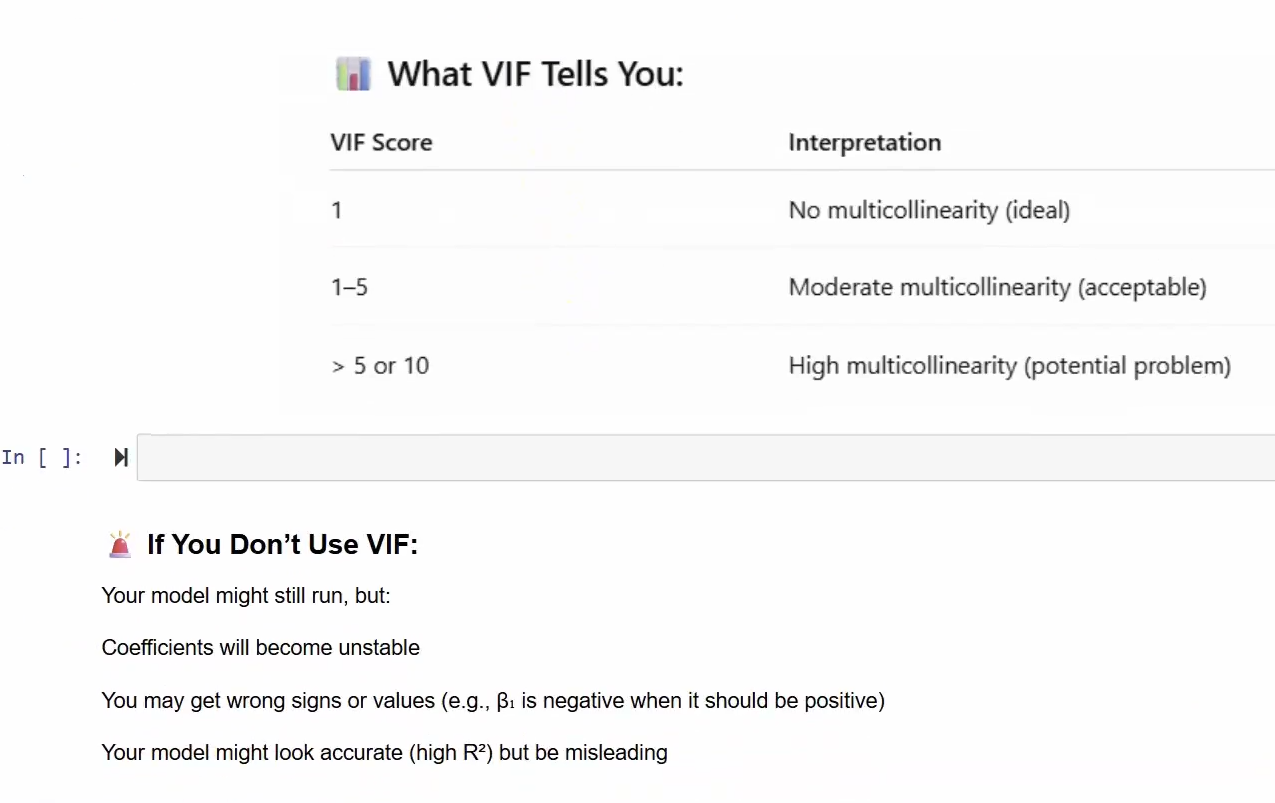

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# from statsmodels.stats.outliers_influence import variance_inflation_factor imports a function to calculate the 
# Variance Inflation Factor (VIF), which measures multicollinearity in regression analysis. 
# It quantifies how much a variable's variance is inflated by correlations with other predictors. 
# VIF > 5-10 indicates high multicollinearity.

In [24]:
# cal vif for each features
vif_data = pd.DataFrame()
vif_data['features'] = X.columns

In [25]:
vif_data

,features
0,TV
1,Newspaper
2,Radio


In [26]:
X.shape

(200, 3)

In [27]:
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# The code says: "Go through every column in my data one by one, calculate its 'redundancy score' (VIF)
# against all other columns, and save those scores in a list."

In [28]:
vif_data

,features,VIF
0,TV,2.486772
1,Newspaper,3.055245
2,Radio,3.285462


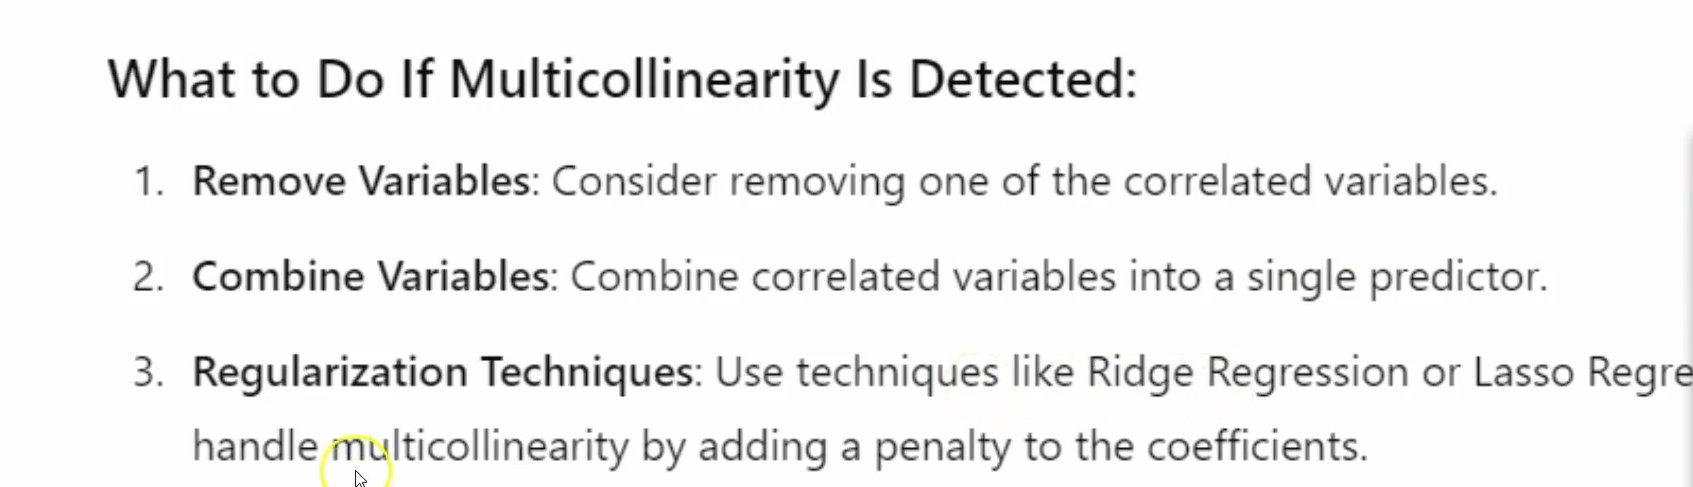

### Split the data into training and testing sets

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)


# X_train, X_test: The "input" data (features) split into two piles.
    
# Y_train, Y_test: The "answers" (labels) split into two piles that match the inputs.
    
# train_test_split(...): The function that does the heavy lifting of scrambling and cutting the data.
    
# X, Y: Your original, full dataset (Features and Targets).
    
# test_size = 0.3: This sets the ratio. 30% of the data goes into the Test set, and the remaining 70% goes into the Train set.
    
# random_state = 42: This is a seed number. It ensures that every time you run this code, the data is split in the exact same way. 
# (The number 42 is a common "lucky" number in coding, but it could be any integer).

In [30]:
X_train.shape

(140, 3)

In [31]:
X_test.shape

(60, 3)

In [32]:
Y_train.shape

(140,)

In [33]:
Y_test.shape

(60,)

### Create and train the model

In [34]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
model.coef_

array([0.05358869, 0.00793167, 0.10270677])

In [36]:
model.intercept_

np.float64(4.743766701589683)

### Make predictions

In [37]:
y_pred = model.predict(X_test)

In [38]:
y_pred

array([17.15991908, 20.53369503, 23.68914396,  9.5191455 , 21.60736836,
       12.78101318, 21.08636345,  8.76054246, 17.11499951, 16.68789636,
        8.97584663,  8.57645026, 18.33212325,  8.17863567, 12.64605571,
       14.94486946,  8.34939536, 17.83858948, 11.12172174, 20.37740648,
       20.9483297 , 13.04035779, 11.01360656, 22.51142595,  9.40369784,
        7.98591291, 20.86943368, 13.77882255, 10.83407064,  8.00419229,
       15.88597618, 10.7027424 , 20.9521718 , 10.84679243, 21.50720813,
       21.07347295, 12.22673775, 22.85273767, 12.57698182,  6.54597206,
       11.93411853, 15.23490068, 10.07411153,  9.52159696, 17.11786382,
        7.28032677, 10.49404864, 15.24356754, 11.20742176, 11.78392665,
       14.01472163, 14.59884572, 10.82722434,  9.55839415,  9.03749681,
       12.51183313, 10.52551021, 25.01900824,  7.99334943, 15.73916263])

In [39]:
test_result = pd.DataFrame({
    'Y_test': Y_test,
    'Y_pred': y_pred
})

In [40]:
print('Testing Data Result:')
test_result.head()

Testing Data Result:


,Y_test,Y_pred
95,16.9,17.159919
15,22.4,20.533695
30,21.4,23.689144
158,7.3,9.519146
128,24.7,21.607368


### Our model is ready. But is it accurate?

In [41]:
print('R_square: ', r2_score(Y_test, y_pred))

R_square:  0.90914843418498


In [42]:
print('RMSE: ', np.sqrt(mean_squared_error(Y_test, y_pred)))

RMSE:  1.5942471691143585


In [43]:
import statsmodels.api as sm

In [44]:
X = sm.add_constant(X_train)
model1 = sm.OLS(Y_train, X).fit()

# statsmodels, intercept isn't automatically added, that's why we use add_constant
# β₀ = intercept
# add_constant() ensures the model calculates this intercept.

# 👉 In statsmodels → Always use add_constant()
# 👉 In sklearn → It is automatic

# but in statsmodels.formula.api, intercept is automatically added

In [45]:
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.892
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     374.3
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.69e-65
Time:                        16:53:04   Log-Likelihood:                -271.70
No. Observations:                 140   AIC:                             551.4
Df Residuals:                     136   BIC:                             563.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.7438      0.400     11.863      0.000       3.953       5.535
TV             0.0536      0.002     30.937      0.000       0.050       0.057
Newspaper      0.0079      0.007      1.064      0.289      -0.007       0.023
Radio          0.1027      0.011      9.726      0.000       0.082       0.124
==============================================================================
Omnibus:                       11.236   Durbin-Watson:                   2.106
Prob(Omnibus):                  0.004   Jarque-Bera (JB):               18.525
Skew:                          -0.374   Prob(JB):                     9.49e-05
Kurtosis:                       4.618   Cond. No.                         500.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### After removing Newspaper, check model perfoamnce

In [46]:
x = data[['TV', 'Radio']]
y = data['Sales']
x.head(), y.head()

(      TV  Radio
 0  230.1   37.8
 1   44.5   39.3
 2   17.2   45.9
 3  151.5   41.3
 4  180.8   10.8,
 0    22.1
 1    10.4
 2    12.0
 3    16.5
 4    17.9
 Name: Sales, dtype: float64)

In [47]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [48]:
x_train.shape, y_train.shape

((140, 2), (140,))

In [49]:
y_test.shape, x_test.shape

((60,), (60, 2))

In [50]:
modelp = LinearRegression()
modelp.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
pred = modelp.predict(x_test)

In [52]:
test_result1 = pd.DataFrame({
    'y_test': y_test,
    'y_pred': pred
})

In [53]:
test_result1.head()

,y_test,y_pred
95,16.9,17.012859
15,22.4,20.448871
30,21.4,23.609103
158,7.3,9.450267
128,24.7,21.922238


In [54]:
print('R-square: ', r2_score(y_test, pred))

R-square:  0.9139189919346896
